In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import matplotlib
import seaborn as sns
import scanpy as sc
import squidpy as sq
import anndata as ad
import scipy.stats as stats
import tacco as tc
import openpyxl
import os
import warnings
warnings.filterwarnings("ignore")

## Load Spatial Object and Collapse Cell Types

In [2]:
adata = sc.read_h5ad('/PATH/TO/SPATIALOBJ')

In [3]:
adata.obs['cell_type_collapsed'] = adata.obs['v2.subclass.l3'].astype(str)

# collapse frPT subtypes
adata.obs.loc[adata.obs['v2.subclass.l3'].isin(['frPT-S1/S2', 'frPT-S3']),
              'cell_type_collapsed'] = 'frPT'

# collapse PT-S1 and PT-S2
adata.obs.loc[adata.obs['v2.subclass.l3'].isin(['PT-S1', 'PT-S2']),
              'cell_type_collapsed'] = 'PT-S1/S2'

# collapse FIB subtypes
fib_types = ['OM-FIB', 'C/M-FIB', 'dIM-FIB', 'IM-FIB', 'C-FIB-OSMRhi',
             'C-FIB-PATH', 'dFIB', 'C-FIB', 'C-FIB-OSMRlo', 'pvFIB',
             'C-MYOF', 'pvFIB-RSPO3+', 'dOM-FIB', 'pvFIB-PI16+',
             'IM-pvMYOF', 'pvMYOF']
adata.obs.loc[adata.obs['v2.subclass.l3'].isin(fib_types),
              'cell_type_collapsed'] = 'FIB'

# collapse IMM subtypes
imm_types = ['resMAC-LYVE1+', 'MON', 'CD8+ TEM/TRM', 'B', 'cDC2', 'Naïve Th',
             'NK', 'MAST', 'resMAC-HLAIIhi', 'MAIT', 'pDC', 'cDC1', 'ncMON',
             'T-REG', 'moMAC-HBEGF+', 'cycT', 'ILC3', 'moMAC-CXCL10+',
             'CD8+ TEM/TEMRA', 'mDC', 'moMAC-C3+', 'cycMAC', 'moFAM']
adata.obs.loc[adata.obs['v2.subclass.l3'].isin(imm_types),
              'cell_type_collapsed'] = 'IMM'

# subset to cell types of interest
cell_types_to_keep = ['aPT1', 'aPT2', 'aPT-S1/S2', 'frPT', 'PT-S1/S2', 'FIB', 'IMM']
adata_subset = adata[adata.obs['cell_type_collapsed'].isin(cell_types_to_keep)].copy()

print(f"Subset: {adata_subset.n_obs} cells")
print(adata_subset.obs['cell_type_collapsed'].value_counts().sort_index())

Subset: 424016 cells
cell_type_collapsed
FIB          210160
IMM           78202
PT-S1/S2      91679
aPT-S1/S2      9117
aPT1          11794
aPT2          13317
frPT           9747
Name: count, dtype: int64


## Obtain Marker Genes from Atlas Object (Differential Expression)

In [4]:
atlas = sc.read_h5ad('/PATH/TO/ATLASOBJ)

In [5]:
# subset atlas to PT cell types
pt_types = ['PT-S1', 'PT-S2', 'PT-S3', 'aPT-S1/S2', 'aPT-S3',
            'aPT1', 'aPT2', 'frPT-S1/S2', 'frPT-S3']
atlas_pt = atlas[atlas.obs['v2.subclass.l3'].isin(pt_types)].copy()

# grouping
atlas_pt.obs['pt_status'] = 'other'
atlas_pt.obs.loc[atlas_pt.obs['v2.subclass.l3'].isin(['PT-S1', 'PT-S2', 'PT-S3']),
                 'pt_status'] = 'healthy_PT'
atlas_pt.obs.loc[atlas_pt.obs['v2.subclass.l3'].isin(['aPT1', 'aPT2']),
                 'pt_status'] = 'altered_PT'

atlas_pt_de = atlas_pt[atlas_pt.obs['pt_status'].isin(['healthy_PT', 'altered_PT'])].copy()

# normalize and log-transform
sc.pp.normalize_total(atlas_pt_de, target_sum=1e4)
sc.pp.log1p(atlas_pt_de)

# differentisl expression (genes upregulated in altered PT vs healthy PT)
sc.tl.rank_genes_groups(atlas_pt_de, groupby='pt_status', method='wilcoxon',
                         reference='healthy_PT', groups=['altered_PT'])

# get significant upregulated genes, filter to spatial gene panel, exclude SOX4/SOX9 for analysis
result_injury = sc.get.rank_genes_groups_df(atlas_pt_de, group='altered_PT')
result_injury = result_injury[result_injury['pvals_adj'] < 0.05]
result_injury = result_injury[result_injury['logfoldchanges'] > 0]
in_panel = result_injury[result_injury['names'].isin(adata.var_names)]
in_panel = in_panel[~in_panel['names'].isin(['SOX4', 'SOX9'])]

print(f"Significant injury genes in Xenium panel: {len(in_panel)}")
print("\nTop 20:")
print(in_panel.head(20)[['names', 'logfoldchanges', 'pvals_adj', 'scores']].to_string())

# final injury signature
injury_sig = in_panel.head(20)['names'].tolist()

# check removal SOX4/SOX9 
injury_sig = [g for g in injury_sig if g not in ['SOX4', 'SOX9']]
print(f"Final injury signature ({len(injury_sig)} genes): {injury_sig}")

Significant injury genes in Xenium panel: 121

Top 20:
       names  logfoldchanges  pvals_adj      scores
0      ITGB8        2.854392        0.0  126.674995
2      DCDC2        2.444582        0.0   98.787750
10     CREB5        2.187215        0.0   83.955574
12     PROM1        3.665242        0.0   82.587799
27     VCAM1        2.966856        0.0   70.071877
28    DLGAP1        2.920990        0.0   69.274223
41    IGFBP7        1.296323        0.0   64.889519
43       VIM        2.699445        0.0   64.005768
46   TNFSF10        1.671161        0.0   62.865101
54    KCTD16        2.968274        0.0   61.616428
60    HAVCR1        2.541777        0.0   60.078888
70      SOD2        1.580263        0.0   57.525852
71     CRYAB        1.996763        0.0   56.854412
74      IL32        2.771664        0.0   56.167164
111     CDH6        1.242393        0.0   50.302120
132     PIGR        2.232658        0.0   47.923100
190      CLU        1.832538        0.0   44.043999
195    HD

## Score and Reclassify aPT1 and aPT2 in Spatial

In [6]:
# score each cell on injury signature (how strongly it expresses selected injury genes)
# cells above median get labeled aPT2, cells below median get labeled aPT1

# subset to only aPT1 and aPT2 cells
apt_mask = adata_subset.obs['cell_type_collapsed'].isin(['aPT1', 'aPT2'])
adata_apt = adata_subset[apt_mask].copy()
print(f"aPT1: {(adata_apt.obs['cell_type_collapsed'] == 'aPT1').sum()}")
print(f"aPT2: {(adata_apt.obs['cell_type_collapsed'] == 'aPT2').sum()}")

# score
injury_sig_final = [g for g in injury_sig if g in adata_subset.var_names]
print(f"Injury signature in panel ({len(injury_sig_final)} genes): {injury_sig_final}")
sc.tl.score_genes(adata_apt, gene_list=injury_sig_final, score_name='injury_score')

# higher injury = aPT2 (early injury), lower = aPT1 (resolving)
median_score = adata_apt.obs['injury_score'].median()
adata_apt.obs['suggested_label'] = np.where(
    adata_apt.obs['injury_score'] > median_score, 'aPT2', 'aPT1')

aPT1: 11794
aPT2: 13317
Injury signature in panel (20 genes): ['ITGB8', 'DCDC2', 'CREB5', 'PROM1', 'VCAM1', 'DLGAP1', 'IGFBP7', 'VIM', 'TNFSF10', 'KCTD16', 'HAVCR1', 'SOD2', 'CRYAB', 'IL32', 'CDH6', 'PIGR', 'CLU', 'HDAC9', 'CLDN1', 'HIF1A']


## Check Results

In [7]:
# for each aPT1 and aPT2 cell type, see the average SOX4 and SOX9 expression
# original labels versus corrected labels

print("SOX4/SOX9 VALIDATION")
print("\nOriginal:")
for ct in ['aPT1', 'aPT2']:
    mask = adata_apt.obs['cell_type_collapsed'] == ct
    sox4 = float(np.asarray(adata_apt[mask, 'SOX4'].X.mean()))
    sox9 = float(np.asarray(adata_apt[mask, 'SOX9'].X.mean()))
    print(f"  {ct}: SOX4={sox4:.3f}, SOX9={sox9:.3f}")

print("\nCorrected:")
for ct in ['aPT1', 'aPT2']:
    mask = adata_apt.obs['suggested_label'] == ct
    sox4 = float(np.asarray(adata_apt[mask, 'SOX4'].X.mean()))
    sox9 = float(np.asarray(adata_apt[mask, 'SOX9'].X.mean()))
    print(f"  {ct}: SOX4={sox4:.3f}, SOX9={sox9:.3f}")

SOX4/SOX9 VALIDATION

Original:
  aPT1: SOX4=0.565, SOX9=0.555
  aPT2: SOX4=0.406, SOX9=0.306

Corrected:
  aPT1: SOX4=0.208, SOX9=0.191
  aPT2: SOX4=0.753, SOX9=0.656


In [8]:
# confusion matrix to check
confusion = pd.crosstab(adata_apt.obs['cell_type_collapsed'],
                         adata_apt.obs['suggested_label'], margins=True)

print("CONFUSION MATRIX")
print(confusion)

print("\nPER-SAMPLE RECLASSIFICATION")
switch_by_sample = adata_apt.obs.groupby('sample_id').apply(
    lambda x: pd.Series({
        'total': len(x),
        'switched': (x['cell_type_collapsed'] != x['suggested_label']).sum(),
        'pct_switched': (x['cell_type_collapsed'] != x['suggested_label']).mean() * 100
    })
)
print(switch_by_sample.to_string())

print("\nSUMMARY")
for ct in ['aPT1', 'aPT2']:
    mask = adata_apt.obs['cell_type_collapsed'] == ct
    n = mask.sum()
    same = (adata_apt.obs.loc[mask, 'suggested_label'] == ct).sum()
    print(f"{ct}: {same}/{n} ({same/n*100:.1f}%) retain, "
          f"{n-same}/{n} ({(n-same)/n*100:.1f}%) switch")

CONFUSION MATRIX
suggested_label       aPT1   aPT2    All
cell_type_collapsed                     
aPT1                  5979   5815  11794
aPT2                  6578   6739  13317
All                  12557  12554  25111

PER-SAMPLE RECLASSIFICATION
            total  switched  pct_switched
sample_id                                
sample1    5480.0    2834.0     51.715328
sample2    3056.0    1339.0     43.815445
sample3    2417.0    1235.0     51.096400
sample4    6087.0    2605.0     42.796123
sample5     846.0     447.0     52.836879
sample6_a  3274.0    1857.0     56.719609
sample6_b  3951.0    2076.0     52.543660

SUMMARY
aPT1: 5979/11794 (50.7%) retain, 5815/11794 (49.3%) switch
aPT2: 6739/13317 (50.6%) retain, 6578/13317 (49.4%) switch


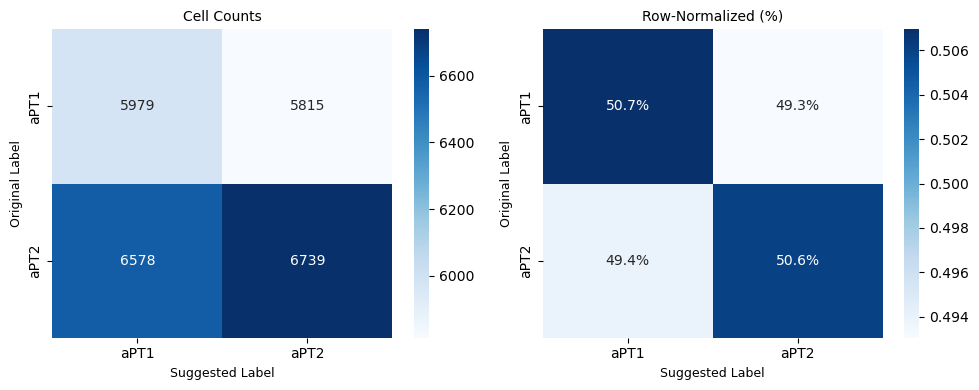

In [9]:
# plot for ease
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# counts
conf_counts = pd.crosstab(adata_apt.obs['cell_type_collapsed'],
                            adata_apt.obs['suggested_label'])
conf_counts = conf_counts.loc[['aPT1', 'aPT2'], ['aPT1', 'aPT2']]

# row normalized 
conf_norm = pd.crosstab(adata_apt.obs['cell_type_collapsed'],
                          adata_apt.obs['suggested_label'], normalize='index')
conf_norm = conf_norm.loc[['aPT1', 'aPT2'], ['aPT1', 'aPT2']]

sns.heatmap(conf_counts, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Suggested Label', fontsize=9)
axes[0].set_ylabel('Original Label', fontsize=9)
axes[0].set_title('Cell Counts', fontsize=10)

sns.heatmap(conf_norm, annot=True, fmt='.1%', cmap='Blues', ax=axes[1])
axes[1].set_xlabel('Suggested Label', fontsize=9)
axes[1].set_ylabel('Original Label', fontsize=9)
axes[1].set_title('Row-Normalized (%)', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=300, bbox_inches='tight')
plt.show()

## Update Labels

In [10]:
# update aPT1/aPT2 labels
adata.obs['cell_type_corrected_collapsed'] = adata.obs['cell_type_collapsed'].astype(str).copy()
adata.obs.loc[adata_apt.obs.index, 'cell_type_corrected_collapsed'] = adata_apt.obs['suggested_label']

adata_subset.obs['cell_type_corrected_collapsed'] = \
    adata.obs.loc[adata_subset.obs.index, 'cell_type_corrected_collapsed']

print(adata.obs.loc[adata.obs['cell_type_corrected_collapsed'].isin(
    ['aPT1', 'aPT2']), 'cell_type_corrected_collapsed'].value_counts())

cell_type_corrected_collapsed
aPT1    12557
aPT2    12554
Name: count, dtype: int64


## Heatmap

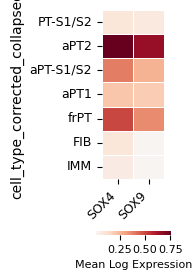

In [11]:
# plot heatmap fig
measured_tfs = ['SOX4', 'SOX9']
cell_types_to_display = ['PT-S1/S2', 'aPT2', 'aPT-S1/S2', 'aPT1', 'frPT', 'FIB', 'IMM']

tf_expr_all = sc.get.obs_df(adata, keys=measured_tfs + ['cell_type_corrected_collapsed'])
mean_expr_all = tf_expr_all.groupby('cell_type_corrected_collapsed')[measured_tfs].mean()
mean_expr_display = mean_expr_all.loc[cell_types_to_display]

plt.figure(figsize=(2, 3))
ax = sns.heatmap(mean_expr_display,
            cmap='RdBu_r',
            center=0,
            cbar_kws={'label': 'Mean Log Expression', 'shrink': 1.2,
                      'orientation': 'horizontal', 'pad': 0.2},
            linewidths=0.5,
            annot=False)
ax.collections[0].colorbar.ax.tick_params(labelsize=8)
ax.collections[0].colorbar.set_label('Mean Log Expression', fontsize=8)
plt.xticks(fontsize=9, rotation=45, ha='right')
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.savefig('TF_heatmap_corrected_final.png', dpi=300, bbox_inches='tight')
plt.show()

## Reordered

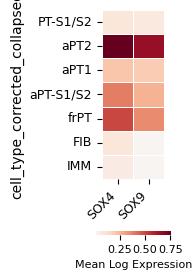

In [12]:
cell_types_to_display = ['PT-S1/S2', 'aPT2', 'aPT1', 'aPT-S1/S2', 'frPT', 'FIB', 'IMM']

tf_expr_all = sc.get.obs_df(adata, keys=measured_tfs + ['cell_type_corrected_collapsed'])
mean_expr_all = tf_expr_all.groupby('cell_type_corrected_collapsed')[measured_tfs].mean()
mean_expr_display = mean_expr_all.loc[cell_types_to_display]

plt.figure(figsize=(2, 3))
ax = sns.heatmap(mean_expr_display,
            cmap='RdBu_r',
            center=0,
            cbar_kws={'label': 'Mean Log Expression', 'shrink': 1.2,
                      'orientation': 'horizontal', 'pad': 0.2},
            linewidths=0.5,
            annot=False)
ax.collections[0].colorbar.ax.tick_params(labelsize=8)
ax.collections[0].colorbar.set_label('Mean Log Expression', fontsize=8)
plt.xticks(fontsize=9, rotation=45, ha='right')
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()

# Save as editable PDF (text stays as text, not rasterized)
plt.savefig('TF_heatmap_final.pdf', dpi=300, bbox_inches='tight', format='pdf')
# Also save SVG as backup (opens in Illustrator/Inkscape)
plt.savefig('TF_heatmap_final.svg', dpi=300, bbox_inches='tight', format='svg')
plt.show()

In [13]:
# print values and cell counts
source_heatmap = mean_expr_display.round(4)
source_heatmap.to_csv('source_data_fig_TF_heatmap.csv')
print(source_heatmap)

cell_counts = adata.obs.loc[
    adata.obs['cell_type_corrected_collapsed'].isin(cell_types_to_display),
    'cell_type_corrected_collapsed'
].value_counts().loc[cell_types_to_display]
cell_counts.to_csv('source_data_fig_cell_counts.csv')
print(cell_counts)

                                 SOX4    SOX9
cell_type_corrected_collapsed                
PT-S1/S2                       0.0912  0.0715
aPT2                           0.7530  0.6556
aPT1                           0.2085  0.1906
aPT-S1/S2                      0.3841  0.2641
frPT                           0.4989  0.3588
FIB                            0.0911  0.0186
IMM                            0.0647  0.0130
cell_type_corrected_collapsed
PT-S1/S2      91679
aPT2          12554
aPT1          12557
aPT-S1/S2      9117
frPT           9747
FIB          210160
IMM           78202
Name: count, dtype: int64
